# OCR – Optičko prepoznavanje karaktera (OCR) 

## Šta je OCR?

*OCR* je skup metoda za pretvaranje slike teksta u mašinski čitljiv tekst.
U ovom projektu fokusiramo se na rukom pisane cifre (0–9), kao prvi korak ka širem OCR sistemu.

Ciljevi -> pravimo bazni OCR model za cifre 0–9:
- učitavanje i priprema MNIST podataka,
- vizuelni pregled uzoraka,
- CNN model i trening,
- evaluacija (accuracy, konfuziona matrica),
- Top-K verovatnoće (analiza grešaka),
- čuvanje/učitavanje modela,
- (opc.) osnova za segmentaciju niza cifara.

Ovo je polazna tačka za prelazak na EMNIST i realne slike iz aplikacije.

Zadatak: data je siva slika dimenzije 28×28 piksela → potrebno je predvideti kojoj klasi (cifri) pripada.
To je problem klasifikacije sa 10 klasa.

### Provera okruženja
Proveravamo verzije i da li je GPU dostupan (nije obavezno, ali je korisno).

---

In [1]:
import sys, pathlib, os

def find_project_root(marker="src", max_up=6):
    p = pathlib.Path.cwd()
    for _ in range(max_up):
        if (p / marker).exists():
            return p
        p = p.parent
    return None

PROJECT_ROOT = find_project_root("src")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Postoji src? ", (PROJECT_ROOT / "src").exists())
print("sys.path[0]  =", sys.path[0])

PROJECT_ROOT = c:\Users\Jovana\Desktop\Faks\Semestri\SestiSemestar\RacunarskaInteligencija\Projekat\OCR
Postoji src?  True
sys.path[0]  = c:\Users\Jovana\Desktop\Faks\Semestri\SestiSemestar\RacunarskaInteligencija\Projekat\OCR


### Učitavanje i priprema MNIST podataka
Učitavamo MNIST, delimo train→train/val, normalizujemo u [0,1] i dodajemo kanal (28×28×1).

---

In [2]:
from src.ocr.data.mnist import load_mnist

(X_train, y_train), (X_val, y_val), (X_test, y_test) = load_mnist()

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Shapes:
Train: (54000, 28, 28, 1) (54000,)
Val:   (6000, 28, 28, 1) (6000,)
Test:  (10000, 28, 28, 1) (10000,)


### Vizuelizacija uzoraka
Brzo proveravamo slike i labele da vidimo da li su podaci korektni.

---

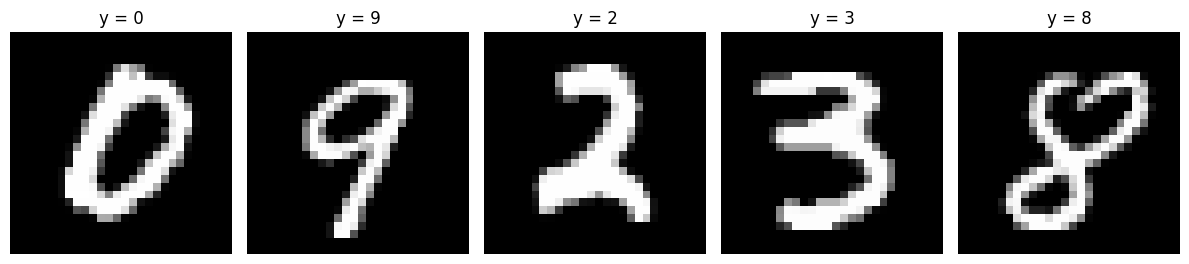

In [3]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 5, figsize=(12,3))
for i in range(5):
    axs[i].imshow(X_train[i].squeeze(), cmap="gray")
    axs[i].set_title(f"y = {y_train[i]}")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

### Definisanje CNN modela

Koristimo funkciju `build_cnn` iz `src/models/cnn.py`.  
Model sadrži:
- sloj za data augmentation (rotacija, translacija, zumiranje, šum),
- 3 konvolutivna bloka (Conv2D + MaxPooling),
- regularizaciju pomoću Dropout-a,
- Dense sloj sa 128 neurona,
- izlazni sloj sa softmax aktivacijom (10 klasa).

Ovo je arhitektura specijalno prilagođena za prepoznavanje rukom pisanih cifara (MNIST).

---

In [4]:
from src.ocr.models.cnn import build_cnn
from keras.optimizers import Adam  # ili from tensorflow.keras.optimizers import Adam

model = build_cnn()
model.compile(optimizer=Adam(),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

### Trening + logovanje (EarlyStopping, Checkpoint, TensorBoard, CSVLogger)

Treniramo CNN i logujemo metrike u artifacts/training_log.csv. Čuvamo najbolji model po val_accuracy.

---

In [15]:
# Trening + logovanje (EarlyStopping, Checkpoint, TensorBoard, CSVLogger)
import datetime
from keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard, CSVLogger, ReduceLROnPlateau
from pathlib import Path

ARTIFACTS = Path(PROJECT_ROOT) / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

checkpoint_path = ARTIFACTS / "mnist_cnn_best.keras"
log_dir        = ARTIFACTS / "logs" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
csv_path       = ARTIFACTS / "training_log.csv"

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(str(checkpoint_path), monitor="val_accuracy", save_best_only=True, verbose=1),
    TensorBoard(log_dir=str(log_dir)),
    CSVLogger(str(csv_path)),   # tvoj plotter čita ovaj CSV
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,              # promeni po želji
    batch_size=128,
    callbacks=callbacks,
    verbose=2
)

print("CSV log:", csv_path)
print("Best model:", checkpoint_path)

Epoch 1/5

Epoch 1: val_accuracy improved from None to 0.98900, saving model to c:\Users\Jovana\Desktop\Faks\Semestri\SestiSemestar\RacunarskaInteligencija\Projekat\OCR\artifacts\mnist_cnn_best.keras
422/422 - 21s - 50ms/step - accuracy: 0.9933 - loss: 0.0212 - val_accuracy: 0.9890 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 2/5

Epoch 2: val_accuracy improved from 0.98900 to 0.98967, saving model to c:\Users\Jovana\Desktop\Faks\Semestri\SestiSemestar\RacunarskaInteligencija\Projekat\OCR\artifacts\mnist_cnn_best.keras
422/422 - 21s - 49ms/step - accuracy: 0.9938 - loss: 0.0195 - val_accuracy: 0.9897 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 3/5

Epoch 3: val_accuracy did not improve from 0.98967
422/422 - 20s - 48ms/step - accuracy: 0.9950 - loss: 0.0154 - val_accuracy: 0.9858 - val_loss: 0.0555 - learning_rate: 0.0010
Epoch 4/5

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy improved from 0.98967 to 0.99200, saving model 

In [16]:
# 1) Sveže učitaj modul (u slučaju da je već bio importovan)
import importlib
import src.ocr.eval.plot_training as pt
importlib.reload(pt)

# 2) Podesi putanje koje želiš (menjamo module-level promenljive)
pt.CSV_PATH = "artifacts/training_log.csv"
pt.OUT_ACC  = "artifacts/accuracy_curve.png"
pt.OUT_LOSS = "artifacts/loss_curve.png"

# 3) Pozovi postojeći main() BEZ argumenata
pt.main()

# 4) Prikaži slike u notebooku
from IPython.display import Image, display
display(Image(filename=pt.OUT_ACC))
display(Image(filename=pt.OUT_LOSS))


FileNotFoundError: Nema artifacts/training_log.csv. Pokreni trening da se CSV generiše.

### Konfuziona matrica
Gde model najviše greši (npr. 6 ↔ 5). Čuvamo i PNG i CSV u `artifacts/`.

---

In [8]:
from pathlib import Path
from src.ocr.eval.evaluate import main  # ako staviš kod u npr. src/ocr/eval/evaluate.py

ARTIFACTS = Path(PROJECT_ROOT) / "artifacts"
main(
    model_path=ARTIFACTS / "mnist_cnn_best.keras",  # ili mnist_cnn_final.keras
    artifacts_dir=ARTIFACTS,
    max_wrong=25
)

TypeError: main() got an unexpected keyword argument 'model_path'

---

### Rezime (MNIST)
- Test accuracy: **~99.24%**
- Artefakti:
  - `artifacts/accuracy_curve.png`, `artifacts/loss_curve.png`
  - `artifacts/confusion_matrix.png` (+ `.csv`)
  - `artifacts/misclassified_samples.png`
  - `artifacts/classification_report.txt` (+ `.csv`)
  - Model: `artifacts/mnist_cnn_best.keras` i `artifacts/mnist_cnn_final.keras`

In [17]:
from pathlib import Path
import cv2
from src.ocr.pipeline import predict_line_from_array, predict_line_string_from_array

img_path = Path(PROJECT_ROOT) / "artifacts" / "sample_images.png"
img = cv2.imread(str(img_path))  # BGR

items = predict_line_from_array(img)
print(items)
print("Predikcija:", predict_line_string_from_array(img))

[(2, 0.40422260761260986)]
Predikcija: 2


In [18]:
import cv2, numpy as np, matplotlib.pyplot as plt
from src.ocr.pipeline import predict_line_from_array

img = cv2.imread(str(img_path))  # BGR
items = predict_line_from_array(img)

vis = img.copy()
for (lbl, conf, (x,y,w,h)) in items:
    cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 2)
    txt = f"{lbl if isinstance(lbl,int) else '?'}:{conf:.2f}"
    cv2.putText(vis, txt, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2, cv2.LINE_AA)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()

ValueError: not enough values to unpack (expected 3, got 2)

In [19]:
from keras.models import load_model
from src.ocr.pipeline import _preprocess_digit_roi  # ili tamo gde je helper

model = load_model(Path(PROJECT_ROOT)/"artifacts"/"mnist_cnn_best.keras")
digits = []
for (lbl, conf, (x,y,w,h)) in items:
    roi = cv2.cvtColor(img[y:y+h, x:x+w], cv2.COLOR_BGR2GRAY)
    xin = _preprocess_digit_roi(roi)
    if xin is None:
        digits.append(("?", []))
        continue
    probs = model.predict(xin, verbose=0)[0]
    top3 = [(int(i), float(probs[i])) for i in np.argsort(probs)[::-1][:3]]
    digits.append((lbl, top3))

print("Niz:", "".join(str(l) if isinstance(l,int) else "?" for l,_ in digits))
for i,(l,top3) in enumerate(digits,1):
    print(f"{i}. {l}  —  {top3}")

ValueError: not enough values to unpack (expected 3, got 2)